In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# =====================================================================
# 1. MEMUAT DATASET SECARA INSTAN VIA JALUR LOKAL KAGGLE (BEBAS UNDUHAN)
# =====================================================================
print("Memuat dataset CIFAR-10 langsung dari penyimpanan lokal...")

# tf.keras.datasets otomatis mengambil berkas lokal jika dijalankan di Kaggle
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalisasi nilai piksel gambar ke rentang [0, 1]
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Membagi data training menjadi Train dan Validation (85% Train, 15% Validation)
val_split = 0.15
split_idx = int(len(x_train_full) * (1 - val_split))

x_train, y_train = x_train_full[:split_idx], y_train_full[:split_idx]
x_val, y_val = x_train_full[split_idx:], y_train_full[split_idx:]

print("✓ Dataset CIFAR-10 berhasil dimuat secara lokal!")
print(f"Jumlah data training  : {x_train.shape[0]} gambar")
print(f"Jumlah data validation: {x_val.shape[0]} gambar")
print(f"Jumlah data testing   : {x_test.shape[0]} gambar")

# =====================================================================
# 2. MEMBANGUN ARSITEKTUR CNN FROM SCRATCH (SINTAKS KERAS 3 TERBARU)
# =====================================================================
model_cnn = models.Sequential([
    # Menggunakan layers.Input sebagai deklarasi dimensi awal (Mencegah UserWarning)
    layers.Input(shape=(32, 32, 3)),
    
    # Blok Konvolusi 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Blok Konvolusi 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flattening & Fully Connected (Dense) Layer
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax') # 10 Kelas Output untuk CIFAR-10
])

# =====================================================================
# 3. KOMPILASI MODEL
# =====================================================================
model_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan ringkasan arsitektur model
model_cnn.summary()

# =====================================================================
# 4. MELATIH MODEL (TRAINING)
# =====================================================================
print("\nMemulai proses training CNN From Scratch...")
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val)
)

# =====================================================================
# 5. EVALUASI AKHIR PADA DATA TESTING
# =====================================================================
test_loss, test_acc = model_cnn.evaluate(x_test, y_test)
print(f"\nAkurasi Akhir CNN from Scratch pada Data Testing: {test_acc * 100:.2f}%")

Memuat dataset CIFAR-10 langsung dari penyimpanan lokal...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2082s 12us/step
✓ Dataset CIFAR-10 berhasil dimuat secara lokal!
Jumlah data training  : 42500 gambar
Jumlah data validation: 7500 gambar
Jumlah data testing   : 10000 gambar


I0000 00:00:1787210433.681171      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,282 (1.38 MB)

 Trainable params: 362,090 (1.38 MB)

 Non-trainable params: 192 (768.00 B)


Memulai proses training CNN From Scratch...
Epoch 1/15
 29/665 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1036 - loss: 2.8683

I0000 00:00:1787210445.657414     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


665/665 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.2687 - loss: 1.9046 - val_accuracy: 0.3520 - val_loss: 1.7794
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4149 - loss: 1.5504 - val_accuracy: 0.5323 - val_loss: 1.2777
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5307 - loss: 1.2997 - val_accuracy: 0.6199 - val_loss: 1.0570
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5886 - loss: 1.1532 - val_accuracy: 0.6620 - val_loss: 0.9560
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6337 - loss: 1.0507 - val_accuracy: 0.6853 - val_loss: 0.8819
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6592 - loss: 0.9737 - val_accuracy: 0.7053 - val_loss: 0.8247
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6795 - loss: 0.9230 - val_accuracy: 0.7132 - val_loss: 0.8135
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6931 - loss: 0.8843 - val_accuracy: 0.7229 - va

Menghitung prediksi model CNN...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


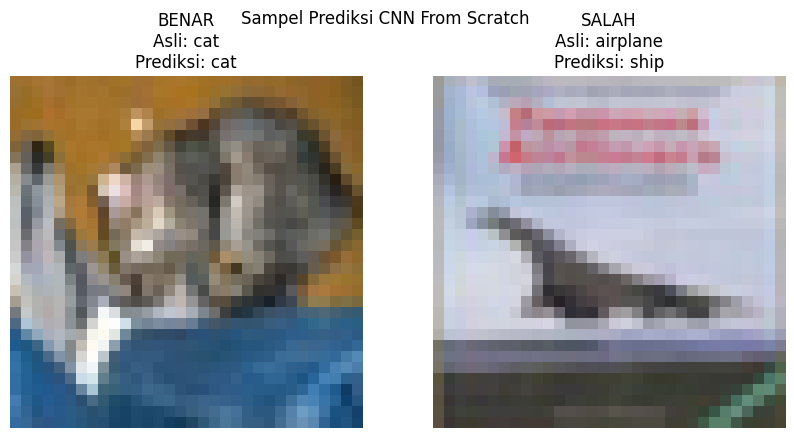

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi kelas CIFAR-10 (mencegah NameError)
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Menghitung prediksi dari model CNN (mencegah NameError y_pred_cnn)
print("Menghitung prediksi model CNN...")
y_pred_cnn = np.argmax(model_cnn.predict(x_test), axis=-1)

# 3. KODE ANDA: Mencari indeks prediksi benar dan salah
correct_idx = np.where(y_pred_cnn == y_test.flatten())[0]
incorrect_idx = np.where(y_pred_cnn != y_test.flatten())[0]

plt.figure(figsize=(10, 5))

# Gambar Benar
plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_idx[0]])
plt.title(f"BENAR\nAsli: {cifar10_classes[y_test.flatten()[correct_idx[0]]]}\nPrediksi: {cifar10_classes[y_pred_cnn[correct_idx[0]]]}")
plt.axis('off')

# Gambar Salah
plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_idx[0]])
plt.title(f"SALAH\nAsli: {cifar10_classes[y_test.flatten()[incorrect_idx[0]]]}\nPrediksi: {cifar10_classes[y_pred_cnn[incorrect_idx[0]]]}")
plt.axis('off')

plt.suptitle("Sampel Prediksi CNN From Scratch")

# 4. Menyimpan file gambar otomatis ke panel output Kaggle
plt.savefig('sampel_prediksi_cnn.png', dpi=300, bbox_inches='tight')

plt.show()

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, optimizers

# =====================================================================
# 1. MEMUAT DATASET ONLINE SECARA INSTAN VIA TFDS (BEBAS DARI HTTP ERROR)
# =====================================================================
print("Sedang memuat dataset Cats vs Dogs dari repositori TensorFlow...")

# Mengunduh langsung data biner yang sudah terverifikasi oleh TensorFlow
# Membagi data langsung menjadi 70% Train, 15% Validation, 15% Test
(train_ds, val_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    with_info=True,
    as_supervised=True  # Mengembalikan format (gambar, label)
)

print(f"✓ Berhasil memuat data!")
print(f"Jumlah sampel training  : {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Jumlah sampel validation: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Jumlah sampel testing   : {tf.data.experimental.cardinality(test_ds).numpy()}")

# =====================================================================
# 2. PROSES RE-SIZE DAN NORMALISASI GAMBAR
# =====================================================================
IMG_SIZE = 160

def format_example(image, label):
    # Mengubah ukuran gambar ke 160x160 piksel
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Normalisasi nilai piksel ke rentang [0, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Terapkan transformasi fungsi pada seluruh batch dataset
train_generator = train_ds.map(format_example).shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)
val_generator = val_ds.map(format_example).batch(16).prefetch(tf.data.AUTOTUNE)
test_generator = test_ds.map(format_example).batch(16).prefetch(tf.data.AUTOTUNE)

# =====================================================================
# 3. TRANSFER LEARNING DENGAN MOBILENETV2
# =====================================================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, 
    weights='imagenet'
)

# Membekukan bobot dasar model (Feature Extraction)
base_model.trainable = False

# Menyusun arsitektur model final sesuai Keras 3
model_tl = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') # Klasifikasi biner Kucing (0) atau Anjing (1)
])

# =====================================================================
# 4. KOMPILASI DAN PROSES TRAINING
# =====================================================================
model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Menjalankan proses training model
history_tl = model_tl.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# =====================================================================
# 5. EVALUASI AKHIR DATA TESTING
# =====================================================================
test_loss, test_acc = model_tl.evaluate(test_generator)
print(f"\nAkurasi Akhir Model Transfer Learning pada Data Testing: {test_acc * 100:.2f}%")

Sedang memuat dataset Cats vs Dogs dari repositori TensorFlow...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.YCQ6G2_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
✓ Berhasil memuat data!
Jumlah sampel training  : 16283
Jumlah sampel validation: 3490
Jumlah sampel testing   : 3489
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 51s 37ms/step - accuracy: 0.9705 - loss: 0.0801 - val_accuracy: 0.9791 - val_loss: 0.0524
Epoch 2/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9837 - loss: 0.0463 - val_accuracy: 0.9822 - val_loss: 0.0456
Epoch 3/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9840 - loss: 0.0432 - val_accuracy: 0.9842 - val_loss: 0.0450
Epoch 4/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9859 - loss: 0.0418 - val_accuracy: 0.9819 - val_loss: 0.0474
Epoch 5/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9855 - loss: 0.0391 - val_accuracy: 0.9814 - val_loss: 0.0568
Epoch 6/10
1018/1018 ━━━━━━━━━━━━━━━━━━━

✓ Visualisasi berhasil disimpan sebagai 'sampel_prediksi_transfer_learning.png'!


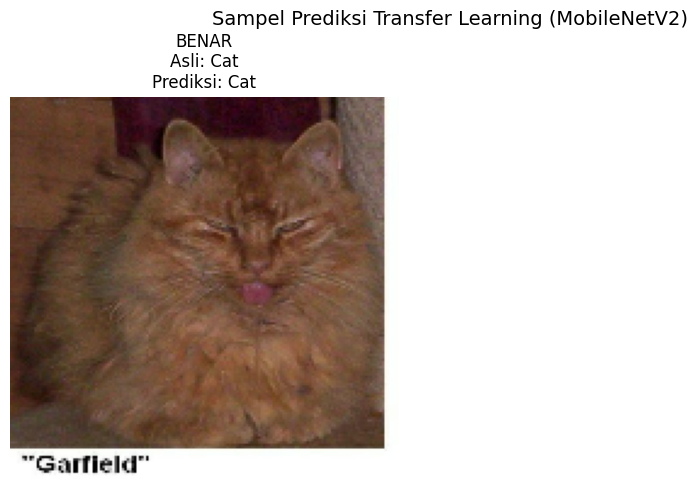

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi daftar kelas untuk Cats vs Dogs (mencegah NameError)
cats_dogs_classes = ['Cat', 'Dog']

# 2. Ambil satu batch dari test generator untuk visualisasi sampling
for images, labels in test_generator.take(1):
    preds = model_tl.predict(images, verbose=0).flatten()
    preds_binary = (preds > 0.5).astype(int)
    labels_np = labels.numpy().astype(int)
    
    correct = np.where(preds_binary == labels_np)[0]
    incorrect = np.where(preds_binary != labels_np)[0]
    
    plt.figure(figsize=(10, 5))
    
    # Menampilkan Gambar Prediksi Benar
    if len(correct) > 0:
        plt.subplot(1, 2, 1)
        # Denormalisasi MobileNetV2 dari rentang [-1, 1] kembali ke [0, 1] untuk matplotlib
        img_show = (images[correct[0]].numpy() + 1) / 2.0
        plt.imshow(np.clip(img_show, 0, 1))
        plt.title(f"BENAR\nAsli: {cats_dogs_classes[labels_np[correct[0]]]}\nPrediksi: {cats_dogs_classes[preds_binary[correct[0]]]}")
        plt.axis('off')
        
    # Menampilkan Gambar Prediksi Salah
    if len(incorrect) > 0:
        plt.subplot(1, 2, 2)
        img_show = (images[incorrect[0]].numpy() + 1) / 2.0
        plt.imshow(np.clip(img_show, 0, 1))
        plt.title(f"SALAH\nAsli: {cats_dogs_classes[labels_np[incorrect[0]]]}\nPrediksi: {cats_dogs_classes[preds_binary[incorrect[0]]]}")
        plt.axis('off')
    
    plt.suptitle("Sampel Prediksi Transfer Learning (MobileNetV2)", fontsize=14)
    plt.tight_layout()
    
    # Simpan file gambar otomatis ke panel output Kaggle
    plt.savefig('sampel_prediksi_transfer_learning.png', dpi=300, bbox_inches='tight')
    print("✓ Visualisasi berhasil disimpan sebagai 'sampel_prediksi_transfer_learning.png'!")
    
    plt.show()
    break

--- VISUALISASI GRAFIK EKSPERIMEN 1 ---
✓ Grafik berhasil disimpan sebagai file: cnn_from_scratch_metrics.png


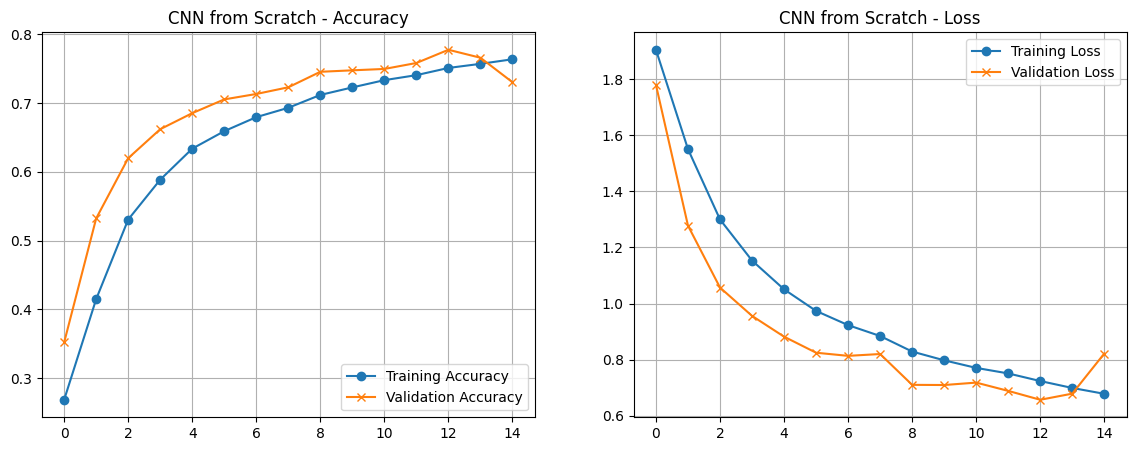


--- VISUALISASI GRAFIK EKSPERIMEN 2 ---
✓ Grafik berhasil disimpan sebagai file: transfer_learning_metrics.png


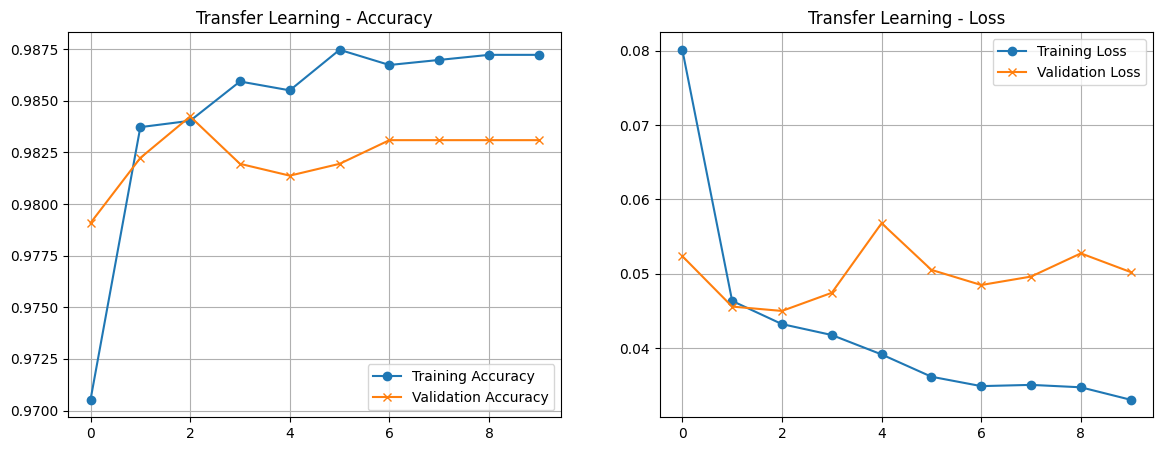

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- CONFUSION MATRIX: CNN FROM SCRATCH ---


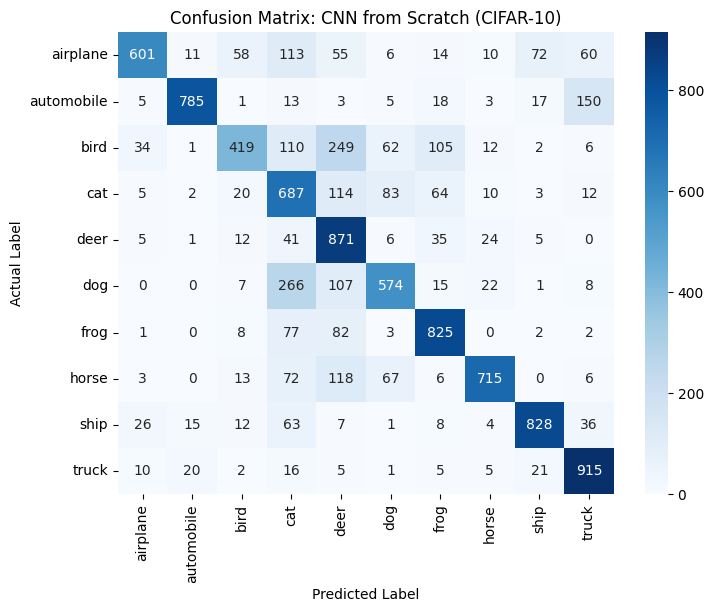


--- CONFUSION MATRIX: TRANSFER LEARNING ---


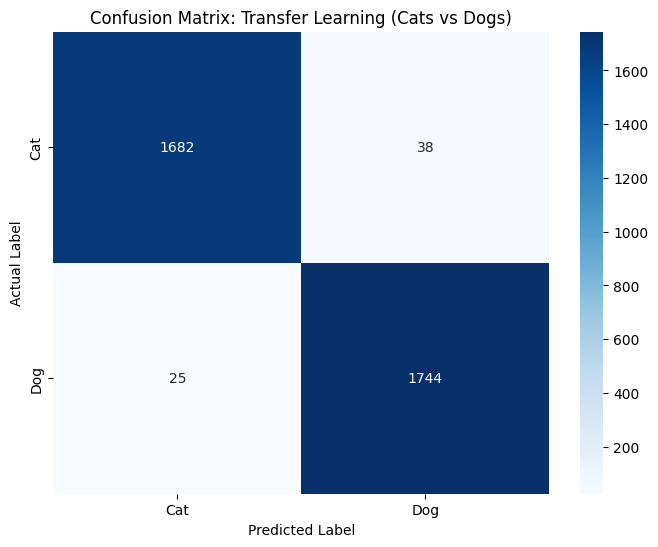

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =====================================================================
# 1 & 2. GRAFIK AKURASI & LOSS TRAINING VS VALIDATION
# =====================================================================
def plot_metrics(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    fig = plt.figure(figsize=(14, 5)) # Ubah sedikit di bagian ini
    
    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.grid(True)
    
    # TAMBAHKAN BARIS INI: Menyimpan grafik menjadi file gambar lokal di Kaggle
    filename = title.lower().replace(" ", "_") + "_metrics.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Grafik berhasil disimpan sebagai file: {filename}")
    
    plt.show()
# Panggil fungsi grafik (pastikan variabel history_cnn dan history_tl Anda masih ada di memori)
print("--- VISUALISASI GRAFIK EKSPERIMEN 1 ---")
plot_metrics(history_cnn, "CNN from Scratch")

print("\n--- VISUALISASI GRAFIK EKSPERIMEN 2 ---")
plot_metrics(history_tl, "Transfer Learning")


# =====================================================================
# 3 & 4. CONFUSION MATRIX UNTUK KEDUA MODEL
# =====================================================================
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# --- 3. Confusion Matrix CNN from Scratch (CIFAR-10) ---
# Mengambil label asli dari test generator biner/numpy
y_pred_cnn = np.argmax(model_cnn.predict(x_test), axis=-1)
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("\n--- CONFUSION MATRIX: CNN FROM SCRATCH ---")
plot_confusion_matrix(y_test.flatten(), y_pred_cnn, cifar10_classes, "CNN from Scratch (CIFAR-10)")

# --- 4. Confusion Matrix Transfer Learning (Cats vs Dogs) ---
# Karena Transfer Learning menggunakan tf.data.Dataset generator, kita ekstraksi manual labelnya
y_true_tl = []
y_pred_tl = []
for images, labels in test_generator:
    preds = model_tl.predict(images, verbose=0)
    # Ubah hasil sigmoid (>0.5 jadi 1, <=0.5 jadi 0)
    preds_binary = (preds > 0.5).astype(int).flatten()
    y_pred_tl.extend(preds_binary)
    y_true_tl.extend(labels.numpy())

cats_dogs_classes = ['Cat', 'Dog']
print("\n--- CONFUSION MATRIX: TRANSFER LEARNING ---")
plot_confusion_matrix(np.array(y_true_tl), np.array(y_pred_tl), cats_dogs_classes, "Transfer Learning (Cats vs Dogs)")